In [1]:
# %pip install ipywidgets

In [2]:
import configparser
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent

def load_config(filename=BASE_DIR / "data/datasets/london_rentals_random.ini"):
    """Parses the config.ini file into a usable dictionary."""
    # Use inline_comment_prefixes to ignore everything after '#'
    config_parser = configparser.ConfigParser(inline_comment_prefixes=('#',))
    config_parser.read(filename)

    c = {}
    
    # PRICE ARGUMENTS Section
    price = config_parser['PRICE_ARGUMENTS']
    c['noise_scale'] = float(price['noise_scale'])
    c['base'] = float(price['base'])
    c['room_coeff'] = float(price['room_coeff'])
    c['distance_coeff'] = float(price['distance_coeff'])
    c['underground_fee'] = float(price['underground_fee'])
    c['house_fee'] = float(price['house_fee'])
    c['garden_fee'] = float(price['garden_fee'])
    c['terrace_fee'] = float(price['terrace_fee'])
    c['balcony_fee'] = float(price['balcony_fee'])
    c['agent_premium'] = float(price['agent_premium'])
    c['market_vol'] = float(price['market_vol'])
    
    return c

config = load_config()

In [3]:
import os

# Disable the C-linker to avoid the relocation/linkage error.
# This will use the Python backend.
os.environ["PYTENSOR_FLAGS"] = "cxx=,linker=py"

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

# Load the NEW dataset with random parameters
df = pd.read_csv("../../data/datasets/london_rentals_random.csv")

# --- SETTING OUR HYPER-PRIORS ---
# These reflect the means of the distributions we used in gen_prop_data.py
# In a real-world scenario, these would be based on historical market data.
VOLATILITY = config['market_vol']

# Mappings for categorical logic (used to prepare the data for PyMC)
df['is_house'] = df['property_type'].map({'House': 1, 'Flat': 0})
df['has_garden'] = (df['outdoor_space'] == 'Garden').astype(int)
df['has_terrace'] = (df['outdoor_space'] == 'Terrace').astype(int)
df['has_balcony'] = (df['outdoor_space'] == 'Balcony').astype(int)

# --- FEATURE ENGINEERING ---
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# We still calculate a baseline expected rent using the means for comparison
INTERCEPT_MU = config['base']
ROOM_MU      = config['room_coeff']
DIST_MU      = config['distance_coeff']
UNDER_MU     = config['underground_fee']
HOUSE_MU     = config['house_fee']
GARDEN_MU    = config['garden_fee']
TERRACE_MU   = config['terrace_fee']
BALCONY_MU   = config['balcony_fee']

df['expected_log_rent_fixed_ref'] = (
    INTERCEPT_MU + 
    (df['n_rooms'] * ROOM_MU) + 
    (df['dist_centre_km'] * DIST_MU) + 
    (df['near_underground'] * UNDER_MU) +
    (df['is_house'] * HOUSE_MU) +
    (df['has_garden'] * GARDEN_MU) +
    (df['has_terrace'] * TERRACE_MU) +
    (df['has_balcony'] * BALCONY_MU)
)

print(f"Dataset loaded: {len(df)} properties.")
print(f"Likelihood assumption: Agent premium follows a Gamma distribution.")
print(f"Likelihood assumption: Beta room value follows a Laplace distribution.")
df[['monthly_rent_gbp', 'log_rent', 'expected_log_rent_fixed_ref']].head()

Dataset loaded: 1000 properties.
Likelihood assumption: Agent premium follows a Gamma distribution.
Likelihood assumption: Beta room value follows a Laplace distribution.


,monthly_rent_gbp,log_rent,expected_log_rent_fixed_ref
0,3166.141767,8.060269,7.887923
1,2148.369926,7.672465,7.638429
2,4978.594328,8.512903,8.440667
3,3950.354354,8.281561,8.196338
4,2193.280657,7.693154,7.675011


In [4]:
# SELECT THE TEST PROPERTY
# We pick one property from our dataset to perform the injection test
idx = 0  # Change this index to test different properties
test_prop = df.iloc[idx]
y_obs = test_prop['log_rent']

print(f"Testing Property ID: {test_prop.get('id', idx)}")
print(f"Observed Log Price: {y_obs:.4f}")
print(f"True Listing Type: {test_prop['listing_type']}")
print("-" * 30)

def run_model_selection(y, prop_data, mc_draws=1000, is_agent_hyp=False):
    """
    Computes the Log-Evidence (log Z) for a specific hypothesis using SMC.
    Optimized to only include relevant structural parameters.
    """
    
    with pm.Model() as model:
        # --- PRIORS: Based on our injection distributions ---
        vol = VOLATILITY
        
        # Market intercept and distance (Gaussian)
        intercept = pm.Normal("intercept", mu=INTERCEPT_MU, sigma=VOLATILITY)
        beta_dist = pm.Normal("beta_dist", mu=DIST_MU, sigma=VOLATILITY)
        
        # Room impact (Laplace)
        beta_room = pm.Laplace("beta_room", mu=ROOM_MU, b=VOLATILITY)
        
        # --- CONDITIONAL STRUCTURAL PRIORS ---
        # Initialize the linear predictor with baseline features
        mu = (
            intercept +
            (prop_data['n_rooms'] * beta_room) +
            (prop_data['dist_centre_km'] * beta_dist)
        )

        # Only define beta_under if the property is near an underground station
        if prop_data['near_underground'] == '1':
            beta_under = pm.Normal("beta_under", mu=UNDER_MU, sigma=VOLATILITY)
            mu += beta_under

        # Only define beta_house if it's a House
        if prop_data['property_type'] == 'House':
            beta_house = pm.Normal("beta_house", mu=HOUSE_MU, sigma=VOLATILITY)
            mu += beta_house
            
        # Only define the specific outdoor prior for the feature present
        outdoor = prop_data['outdoor_space']
        if outdoor == 'Garden':
            beta_garden = pm.Normal("beta_garden", mu=GARDEN_MU, sigma=VOLATILITY)
            mu += beta_garden
        elif outdoor == 'Terrace':
            beta_terrace = pm.Normal("beta_terrace", mu=TERRACE_MU, sigma=VOLATILITY)
            mu += beta_terrace
        elif outdoor == 'Balcony':
            beta_balcony = pm.Normal("beta_balcony", mu=BALCONY_MU, sigma=VOLATILITY)
            mu += beta_balcony
        
        # --- AGENT PREMIUM LOGIC ---
        if is_agent_hyp:
            alpha = (config['agent_premium'] / VOLATILITY)**2
            beta = config['agent_premium'] / (VOLATILITY**2)
            premium = pm.Gamma("premium", alpha=alpha, beta=beta)
            mu += premium
        
        # --- LIKELIHOOD ---
        pm.StudentT("obs", nu=5, mu=mu, sigma=config['noise_scale'], observed=y)
        
        # --- MARGINAL LIKELIHOOD ESTIMATION ---
        trace = pm.sample_smc(
            draws=mc_draws, 
            chains=4, 
            progressbar=True,
            return_inferencedata=True,
        )
        
        return trace

# COMPUTE LOG-EVIDENCE FOR BOTH MODELS
# We take the mean across chains
mc_draws = 1000
print("Calculating Evidence for Owner Model...")
owner = run_model_selection(y_obs, test_prop, mc_draws=mc_draws, is_agent_hyp=False)
log_z_owner = owner.sample_stats.log_marginal_likelihood.mean().item()

print("Calculating Evidence for Agent Model...")
agent = run_model_selection(y_obs, test_prop, mc_draws=mc_draws, is_agent_hyp=True)
log_z_agent = agent.sample_stats.log_marginal_likelihood.mean().item()

# INTERPRETATION
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- RESULTS ---")
print(f"Log Z (Owner): {log_z_owner:.4f}")
print(f"Log Z (Agent): {log_z_agent:.4f}")
print(f"Bayes Factor (K): {BF:.4f}")

if BF > 10:
    print("Conclusion: Strong Evidence for AGENT model.")
elif BF < 0.1:
    print("Conclusion: Strong Evidence for OWNER model.")
else:
    print("Conclusion: Ambiguous Evidence (Inconclusive).")

Initializing SMC sampler...


Testing Property ID: 0
Observed Log Price: 8.0603
True Listing Type: Owner
------------------------------
Calculating Evidence for Owner Model...


Sampling 4 chains sequentially


Output()

/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
Initializing SMC sampler...


Calculating Evidence for Agent Model...


Sampling 4 chains sequentially


Output()


--- RESULTS ---
Log Z (Owner): 0.3263
Log Z (Agent): 0.7050
Bayes Factor (K): 1.4604
Conclusion: Ambiguous Evidence (Inconclusive).


/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


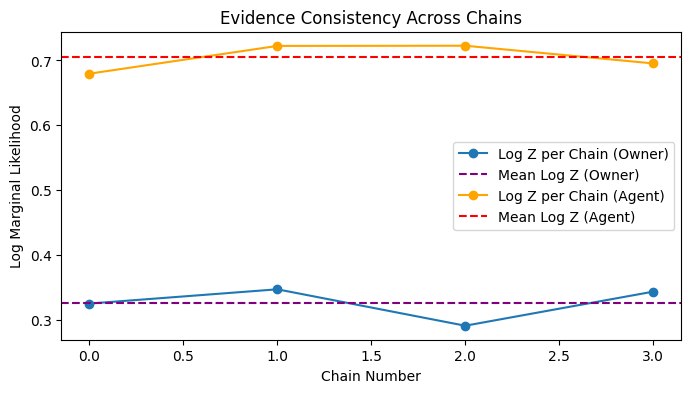

In [5]:
# Access the log_marginal_likelihood per chain
# This shows if all 4 chains reached roughly the same conclusion
log_z_per_chain_owner = np.array([chain[~np.isnan(chain.astype(float))][0] for chain in owner.sample_stats.log_marginal_likelihood.values])
log_z_per_chain_agent = np.array([chain[~np.isnan(chain.astype(float))][0] for chain in agent.sample_stats.log_marginal_likelihood.values])

plt.figure(figsize=(8, 4))
plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')
plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.legend()
plt.show()

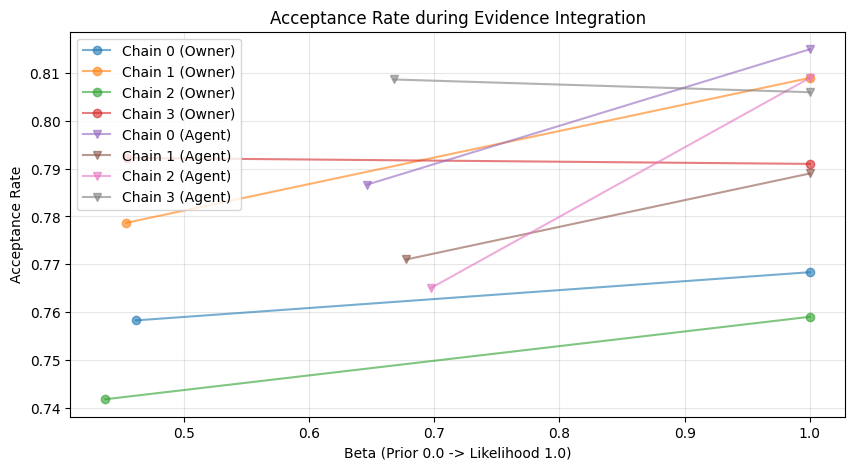

In [6]:
accept_rates_owner = owner.sample_stats["accept_rate"].values
betas_owner = owner.sample_stats["beta"].values
accept_rates_agent = agent.sample_stats["accept_rate"].values
betas_agent = agent.sample_stats["beta"].values

plt.figure(figsize=(10, 5))

# Plotting the acceptance rate across stages
for i in range(accept_rates_owner.shape[0]):
    plt.plot(betas_owner[i], accept_rates_owner[i], 'o-', alpha=0.6, label=f'Chain {i} (Owner)')
for i in range(accept_rates_agent.shape[0]):
    plt.plot(betas_agent[i], accept_rates_agent[i], 'v-', alpha=0.6, label=f'Chain {i} (Agent)')
plt.xlabel('Beta (Prior 0.0 -> Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate during Evidence Integration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

OWNER



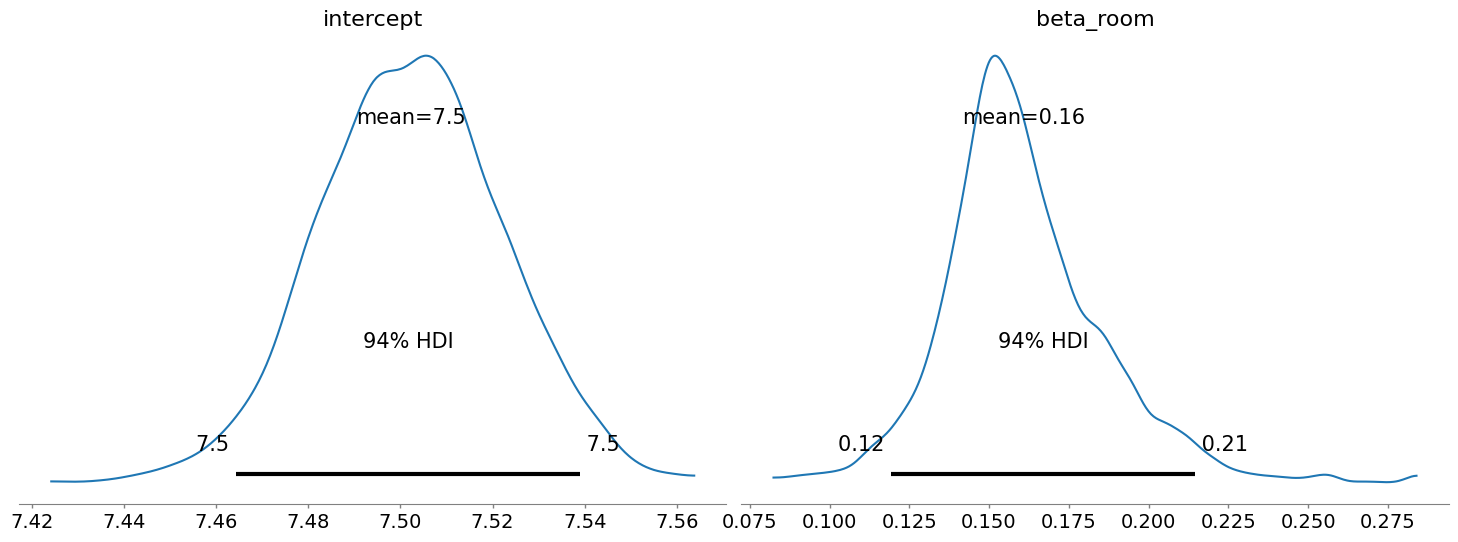

AGENT



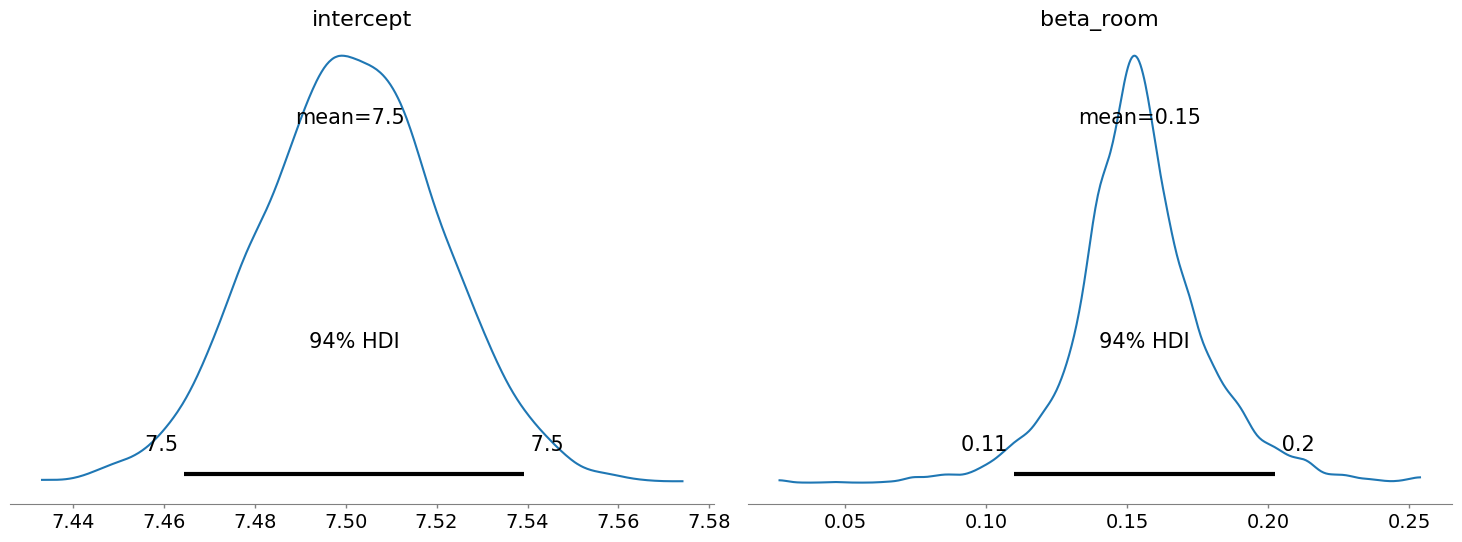

In [7]:
# Plot the distribution of the parameters after seeing the data
print("OWNER")
print("")
az.plot_posterior(owner, var_names=['intercept', 'beta_room'])
plt.tight_layout()
plt.show()

print("AGENT")
print("")
az.plot_posterior(agent, var_names=['intercept', 'beta_room'])
plt.tight_layout()
plt.show()

In [8]:
# --- POSTERIOR PREDICTIVE CHECK (OWNER) ---
with pm.Model() as model:
    vol = VOLATILITY
    
    intercept = pm.Normal("intercept", mu=INTERCEPT_MU, sigma=VOLATILITY)
    beta_dist = pm.Normal("beta_dist", mu=DIST_MU, sigma=VOLATILITY)
    beta_room = pm.Laplace("beta_room", mu=ROOM_MU, b=VOLATILITY)
    
    mu = (
        intercept +
        (test_prop['n_rooms'] * beta_room) +
        (test_prop['dist_centre_km'] * beta_dist)
    )

    if test_prop['near_underground'] == '1':
        beta_under = pm.Normal("beta_under", mu=UNDER_MU, sigma=VOLATILITY)
        mu += beta_under
    if test_prop['property_type'] == 'House':
        beta_house = pm.Normal("beta_house", mu=HOUSE_MU, sigma=VOLATILITY)
        mu += beta_house
    outdoor = test_prop['outdoor_space']
    if outdoor == 'Garden':
        beta_garden = pm.Normal("beta_garden", mu=GARDEN_MU, sigma=VOLATILITY)
        mu += beta_garden
    elif outdoor == 'Terrace':
        beta_terrace = pm.Normal("beta_terrace", mu=TERRACE_MU, sigma=VOLATILITY)
        mu += beta_terrace
    elif outdoor == 'Balcony':
        beta_balcony = pm.Normal("beta_balcony", mu=BALCONY_MU, sigma=VOLATILITY)
        mu += beta_balcony
    
    pm.StudentT("obs", nu=5, mu=mu, sigma=config['noise_scale'], observed=y_obs)
        
    # We sample the predictive distribution using the 'owner' trace calculated earlier
    pm.sample_posterior_predictive(owner, extend_inferencedata=True)

# --- POSTERIOR PREDICTIVE CHECK (AGENT) ---
with pm.Model() as model:
    vol = VOLATILITY
    
    intercept = pm.Normal("intercept", mu=INTERCEPT_MU, sigma=VOLATILITY)
    beta_dist = pm.Normal("beta_dist", mu=DIST_MU, sigma=VOLATILITY)
    beta_room = pm.Laplace("beta_room", mu=ROOM_MU, b=VOLATILITY)
    
    mu = (
        intercept +
        (test_prop['n_rooms'] * beta_room) +
        (test_prop['dist_centre_km'] * beta_dist)
    )

    if test_prop['near_underground'] == '1':
        beta_under = pm.Normal("beta_under", mu=UNDER_MU, sigma=VOLATILITY)
        mu += beta_under
    if test_prop['property_type'] == 'House':
        beta_house = pm.Normal("beta_house", mu=HOUSE_MU, sigma=VOLATILITY)
        mu += beta_house
    outdoor = test_prop['outdoor_space']
    if outdoor == 'Garden':
        beta_garden = pm.Normal("beta_garden", mu=GARDEN_MU, sigma=VOLATILITY)
        mu += beta_garden
    elif outdoor == 'Terrace':
        beta_terrace = pm.Normal("beta_terrace", mu=TERRACE_MU, sigma=VOLATILITY)
        mu += beta_terrace
    elif outdoor == 'Balcony':
        beta_balcony = pm.Normal("beta_balcony", mu=BALCONY_MU, sigma=VOLATILITY)
        mu += beta_balcony
    
    alpha = (config['agent_premium'] / VOLATILITY)**2
    beta = config['agent_premium'] / (VOLATILITY**2)
    premium = pm.Gamma("premium", alpha=alpha, beta=beta)
    mu += premium
    
    pm.StudentT("obs", nu=5, mu=mu, sigma=config['noise_scale'], observed=y_obs)
        
    # We sample the predictive distribution using the 'agent' trace calculated earlier
    pm.sample_posterior_predictive(agent, extend_inferencedata=True)

Sampling: [obs]


Output()

Sampling: [obs]


Output()

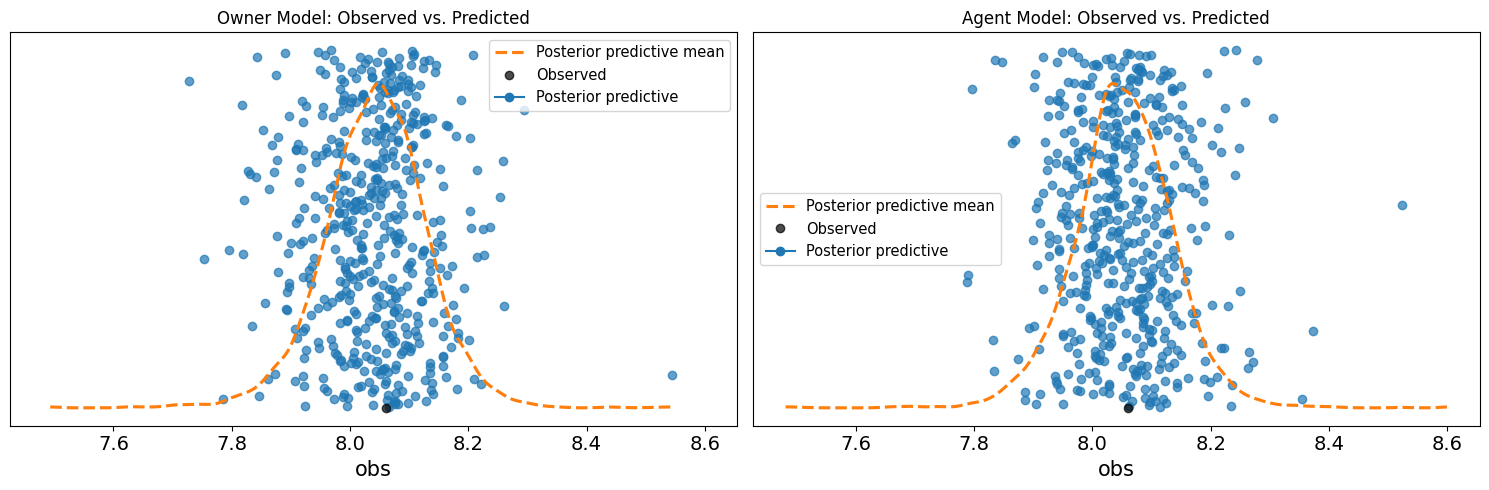

In [9]:
# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Owner
az.plot_ppc(owner, kind="scatter", num_pp_samples=500, ax=axes[0])
axes[0].set_title("Owner Model: Observed vs. Predicted")

# Plot Agent
az.plot_ppc(agent, kind="scatter", num_pp_samples=500, ax=axes[1])
axes[1].set_title("Agent Model: Observed vs. Predicted")

plt.tight_layout()
plt.show()

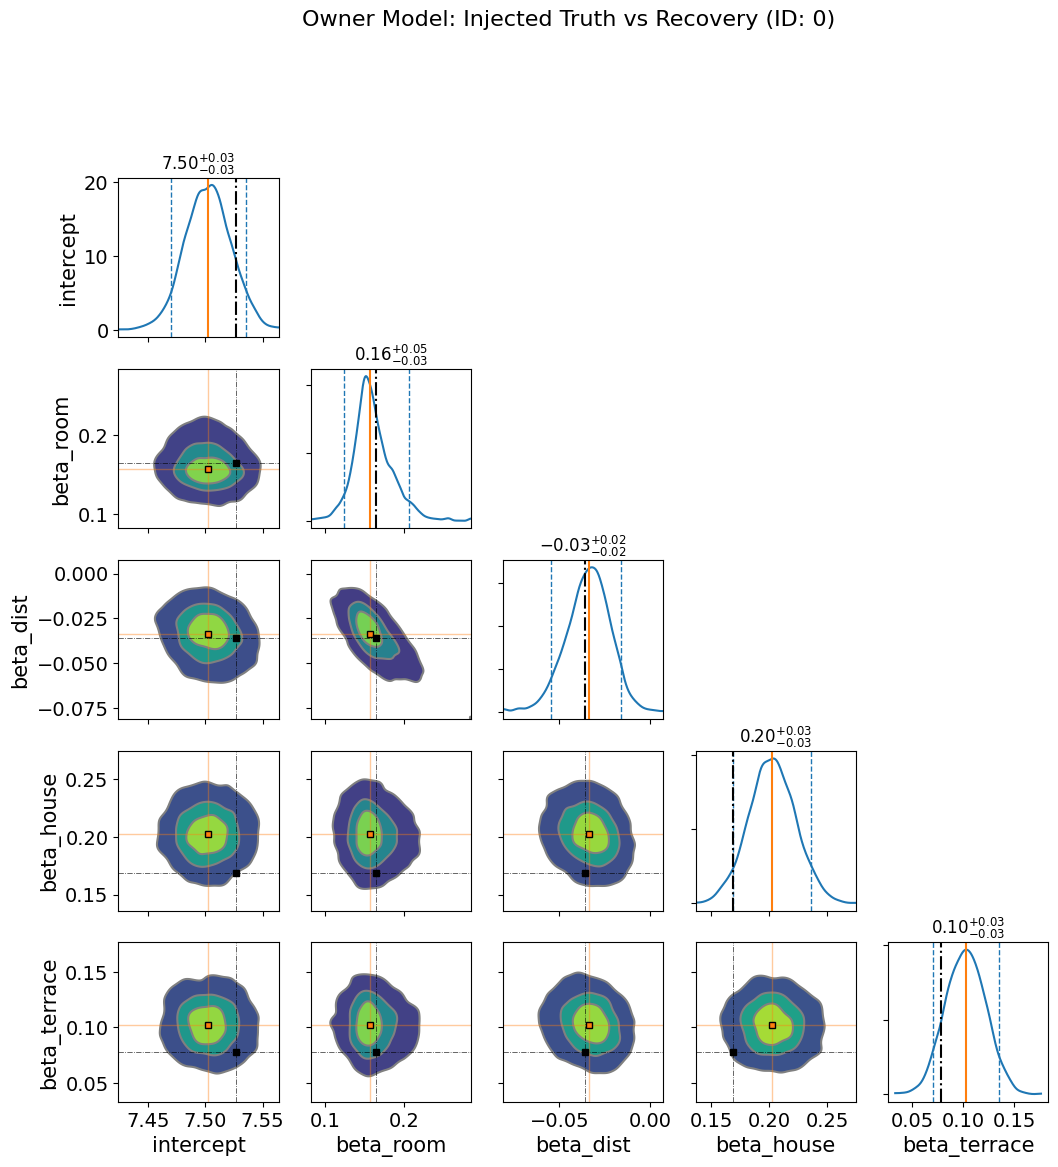

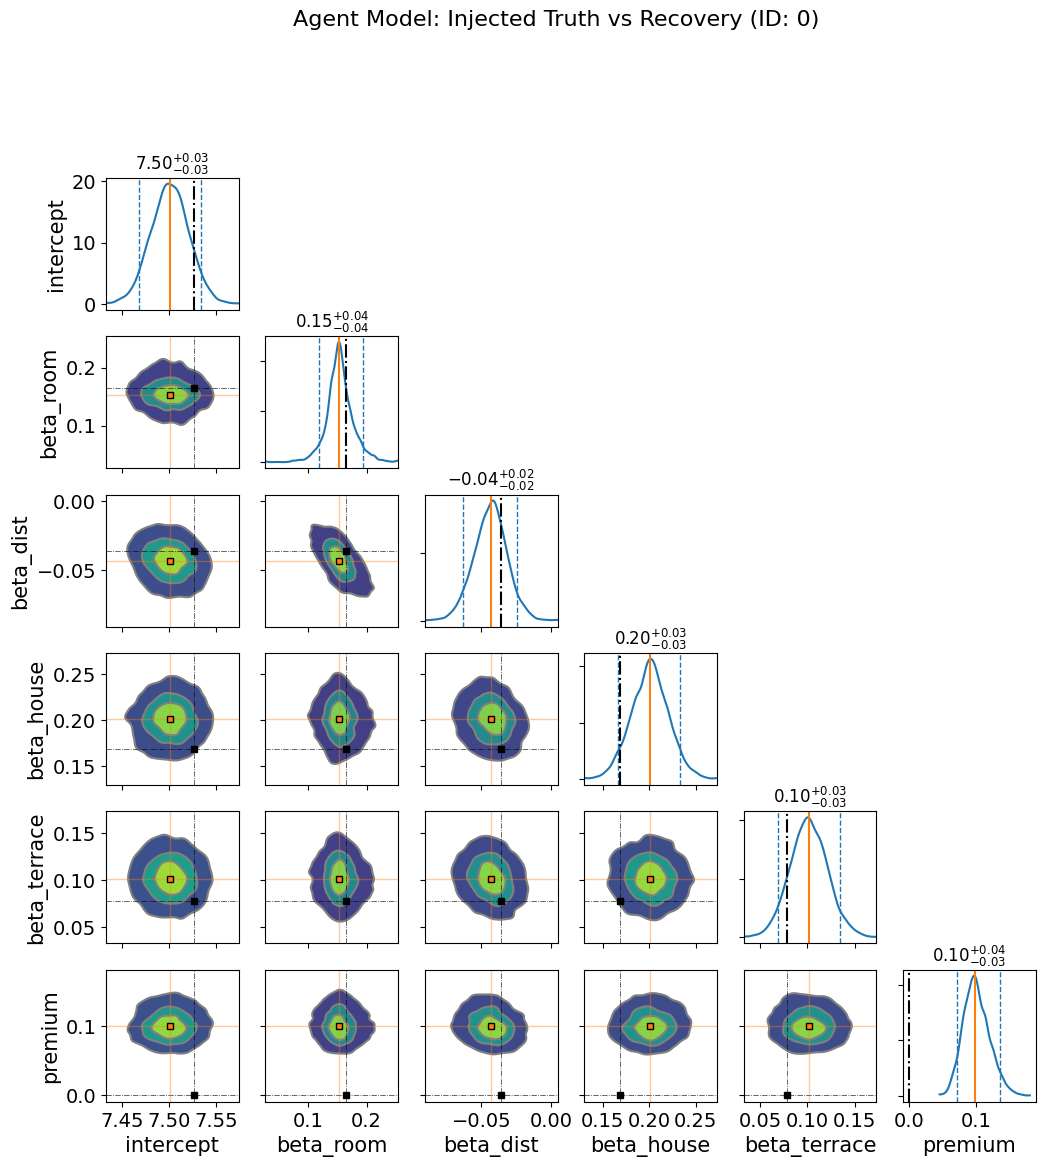

In [10]:
# --- DYNAMIC VARIABLE SELECTION & TRUTH MAPPING ---
base_vars = ["intercept", "beta_room", "beta_dist"]
structural_vars = []

if test_prop['near_underground'] == 1:
    structural_vars.append("beta_under")

if test_prop['property_type'] == 'House':
    structural_vars.append("beta_house")

outdoor = test_prop['outdoor_space']
if outdoor in ['Garden', 'Terrace', 'Balcony']:
    structural_vars.append(f"beta_{outdoor.lower()}")

owner_vars = base_vars + structural_vars
agent_vars = owner_vars + ["premium"]

truth_values = {
    "intercept": test_prop["intercept"],
    "beta_room": test_prop["beta_room"],
    "beta_dist": test_prop["beta_dist"],
    "beta_under": test_prop["beta_under"],
    "beta_house": test_prop["beta_prop"],
    "beta_garden": test_prop["beta_outdoor"],
    "beta_terrace": test_prop["beta_outdoor"],
    "beta_balcony": test_prop["beta_outdoor"],
    "premium": test_prop["premium"]
}

# --- OWNER MODEL CORNER PLOT ---
stats_owner = {v: float(owner.posterior[v].median()) for v in owner_vars}

axes_owner = az.plot_pair(
    owner,
    var_names=owner_vars,
    kind='kde',
    marginals=True,
    reference_values=stats_owner,
    reference_values_kwargs={'color': 'C1', 'marker': 's', 'markersize': 4, 'zorder': 10},
    figsize=(12, 12),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

rows, cols = axes_owner.shape
for i in range(rows):
    for j in range(cols):
        ax = axes_owner[i, j]
        if ax is None: continue
        
        var_i = owner_vars[i]
        if i == j:
            # 1D Posterior + Truth Line
            data = owner.posterior[var_i].values.flatten()
            q_low, med, q_high = np.percentile(data, [5, 50, 95])
            ax.axvline(q_low, color='C0', linestyle='--', linewidth=1)
            ax.axvline(q_high, color='C0', linestyle='--', linewidth=1)
            ax.axvline(med, color='C1', linestyle='-', linewidth=1.5)
            # Injected Truth Line (Black Dash-Dot)
            ax.axvline(truth_values[var_i], color='black', linestyle='-.', linewidth=1.5)
            
            upper, lower = q_high - med, med - q_low
            ax.set_title(f"${med:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=12)
        elif i > j:
            # 2D Posterior
            var_j = owner_vars[j]
            
            # --- Injected Truth Crosshair ---
            ax.axvline(truth_values[var_j], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            ax.axhline(truth_values[var_i], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            # Truth Square
            ax.plot(truth_values[var_j], truth_values[var_i], 
                    marker='s', color='black', markersize=5, zorder=11)
            
            # --- Median Reference lines (Orange) ---
            ax.axvline(stats_owner[var_j], color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(stats_owner[var_i], color='C1', linestyle='-', linewidth=1, alpha=0.4)

plt.suptitle(f"Owner Model: Injected Truth vs Recovery (ID: {test_prop.get('id', idx)})", fontsize=16, y=1.02)
plt.show()

# --- AGENT MODEL CORNER PLOT ---
stats_agent = {v: float(agent.posterior[v].median()) for v in agent_vars}

axes_agent = az.plot_pair(
    agent,
    var_names=agent_vars,
    kind='kde',
    marginals=True,
    reference_values=stats_agent,
    reference_values_kwargs={'color': 'C1', 'marker': 's', 'markersize': 4, 'zorder': 10},
    figsize=(12, 12),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

rows, cols = axes_agent.shape
for i in range(rows):
    for j in range(cols):
        ax = axes_agent[i, j]
        if ax is None: continue
        
        var_i = agent_vars[i]
        if i == j:
            # 1D Posterior + Truth Line
            data = agent.posterior[var_i].values.flatten()
            q_low, med, q_high = np.percentile(data, [5, 50, 95])
            ax.axvline(q_low, color='C0', linestyle='--', linewidth=1)
            ax.axvline(q_high, color='C0', linestyle='--', linewidth=1)
            ax.axvline(med, color='C1', linestyle='-', linewidth=1.5)
            # Injected Truth Line (Black Dash-Dot)
            ax.axvline(truth_values[var_i], color='black', linestyle='-.', linewidth=1.5)
            
            upper, lower = q_high - med, med - q_low
            ax.set_title(f"${med:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=12)
        elif i > j:
            # 2D Posterior
            var_j = agent_vars[j]
            
            # --- Injected Truth Crosshair ---
            ax.axvline(truth_values[var_j], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            ax.axhline(truth_values[var_i], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            # Truth Square
            ax.plot(truth_values[var_j], truth_values[var_i], 
                    marker='s', color='black', markersize=5, zorder=11)
            
            # --- Median Reference lines (Orange) ---
            ax.axvline(stats_agent[var_j], color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(stats_agent[var_i], color='C1', linestyle='-', linewidth=1, alpha=0.4)

plt.suptitle(f"Agent Model: Injected Truth vs Recovery (ID: {test_prop.get('id', idx)})", fontsize=16, y=1.02)
plt.show()

In [11]:
# Focus only on the main slopes and intercept
print("OWNER")
print("")
stats = az.summary(owner)
print(stats)
print("")

print("AGENT")
print("")
stats = az.summary(agent)
print(stats)

OWNER

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept     7.502  0.020   7.464    7.539        0.0    0.000    4059.0   
beta_dist    -0.034  0.012  -0.056   -0.011        0.0    0.000    3508.0   
beta_room     0.161  0.025   0.119    0.214        0.0    0.001    3484.0   
beta_house    0.202  0.020   0.165    0.241        0.0    0.000    3304.0   
beta_terrace  0.102  0.020   0.068    0.141        0.0    0.000    3311.0   

              ess_tail  r_hat  
intercept       3592.0    1.0  
beta_dist       3236.0    1.0  
beta_room       2712.0    1.0  
beta_house      3683.0    1.0  
beta_terrace    3595.0    1.0  

AGENT

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept     7.501  0.020   7.465    7.539        0.0      0.0    3772.0   
beta_dist    -0.044  0.012  -0.067   -0.022        0.0      0.0    3713.0   
beta_room     0.154  0.023   0.110    0.202        0.0      0.0    3813.0   
beta_house    0.201  0

In [12]:
results = []

# --- COMPUTE Z-SCORES FOR OWNER MODEL ---
for var in owner_vars:
    post_samples = owner.posterior[var].values.flatten()
    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = truth_values[var]
    
    z_score = (post_median - injected_truth) / post_sd
    
    results.append({
        "Model": "Owner",
        "Parameter": var,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score
    })

# --- COMPUTE Z-SCORES FOR AGENT MODEL ---
for var in agent_vars:
    post_samples = agent.posterior[var].values.flatten()
    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = truth_values[var]
    
    z_score = (post_median - injected_truth) / post_sd
    
    results.append({
        "Model": "Agent",
        "Parameter": var,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score
    })

# --- DISPLAY RESULTS ---
from matplotlib.colors import LinearSegmentedColormap

# Create a symmetric map: Red (-3) -> Green (0) -> Red (+3)
cmap_symmetric = LinearSegmentedColormap.from_list("Z_map", ["#d73027", "#1a9850", "#d73027"])

z_score_df = pd.DataFrame(results)

print(f"Recovery Analysis for Property ID: {test_prop.get('id', idx)}")
display(z_score_df.style.format({
    "Injected Truth": "{:.3f}",
    "Posterior Median": "{:.3f}",
    "Posterior SD": "{:.3f}",
    "Z-Score": "{:.2f}"
}).background_gradient(subset=['Z-Score'], cmap=cmap_symmetric, vmin=-3, vmax=3))

# Quick Interpretation
print("\nInterpretation Guide:")
print("- |Z| < 1.0: Excellent recovery (Truth is in the 'inner core').")
print("- 1.0 < |Z| < 2.0: Good recovery (Truth is within 95% of expected area).")
print("- |Z| > 2.0: Potential outlier or model bias for this specific run.")

Recovery Analysis for Property ID: 0


,Model,Parameter,Injected Truth,Posterior Median,Posterior SD,Z-Score
0,Owner,intercept,7.527,7.502,0.020,-1.22
1,Owner,beta_room,0.165,0.158,0.025,-0.28
2,Owner,beta_dist,-0.036,-0.033,0.012,0.22
3,Owner,beta_house,0.169,0.202,0.020,1.69
4,Owner,beta_terrace,0.078,0.102,0.020,1.23
5,Agent,intercept,7.527,7.501,0.020,-1.28
6,Agent,beta_room,0.165,0.153,0.023,-0.48
7,Agent,beta_dist,-0.036,-0.043,0.012,-0.59
8,Agent,beta_house,0.169,0.201,0.020,1.61
9,Agent,beta_terrace,0.078,0.101,0.020,1.17



Interpretation Guide:
- |Z| < 1.0: Excellent recovery (Truth is in the 'inner core').
- 1.0 < |Z| < 2.0: Good recovery (Truth is within 95% of expected area).
- |Z| > 2.0: Potential outlier or model bias for this specific run.


In [13]:
# --- PREPARE TWO-TAILED P-VALUE DATASET ---
two_tailed_results = []

def compute_two_tailed_p_val(samples, truth):
    """
    Calculates the two-tailed Bayesian p-value.
    Defined as 2 * min(Pr(theta > truth), Pr(theta < truth)).
    Value of 1.0 = Truth is the median.
    Value < 0.05 = Truth is a significant outlier.
    """
    prob_greater = np.mean(samples > truth)
    prob_less = np.mean(samples < truth)
    return 2 * min(prob_greater, prob_less)

# --- COMPUTE FOR OWNER MODEL ---
for var in owner_vars:
    post_samples = owner.posterior[var].values.flatten()
    injected_truth = truth_values[var]
    
    p_val = compute_two_tailed_p_val(post_samples, injected_truth)
    
    two_tailed_results.append({
        "Model": "Owner",
        "Parameter": var,
        "Injected Truth": injected_truth,
        "Posterior Median": np.median(post_samples),
        "Two-Tailed p-value": p_val,
        "Recovery Status": "Success" if p_val >= 0.05 else "Outlier"
    })

# --- COMPUTE FOR AGENT MODEL ---
for var in agent_vars:
    post_samples = agent.posterior[var].values.flatten()
    injected_truth = truth_values[var]
    
    p_val = compute_two_tailed_p_val(post_samples, injected_truth)
    
    two_tailed_results.append({
        "Model": "Agent",
        "Parameter": var,
        "Injected Truth": injected_truth,
        "Posterior Median": np.median(post_samples),
        "Two-Tailed p-value": p_val,
        "Recovery Status": "Success" if p_val >= 0.05 else "Outlier"
    })

# --- DISPLAY RESULTS ---
two_tailed_df = pd.DataFrame(two_tailed_results)

print(f"Two-Tailed Recovery Analysis (ID: {test_prop.get('id', idx)})")
display(two_tailed_df.style.format({
    "Injected Truth": "{:.3f}",
    "Posterior Median": "{:.3f}",
    "Two-Tailed p-value": "{:.3f}"
}).background_gradient(subset=['Two-Tailed p-value'], cmap='RdYlGn', vmin=0, vmax=1))

# Final Interpretation
print("\nDeep-Dive Interpretation:")
print("- p-value > 0.05: We fail to reject that the injected truth is a plausible value for this parameter.")
print("- p-value < 0.05: The truth is statistically inconsistent with this specific posterior.")

Two-Tailed Recovery Analysis (ID: 0)


,Model,Parameter,Injected Truth,Posterior Median,Two-Tailed p-value,Recovery Status
0,Owner,intercept,7.527,7.502,0.221,Success
1,Owner,beta_room,0.165,0.158,0.739,Success
2,Owner,beta_dist,-0.036,-0.033,0.829,Success
3,Owner,beta_house,0.169,0.202,0.098,Success
4,Owner,beta_terrace,0.078,0.102,0.224,Success
5,Agent,intercept,7.527,7.501,0.197,Success
6,Agent,beta_room,0.165,0.153,0.547,Success
7,Agent,beta_dist,-0.036,-0.043,0.514,Success
8,Agent,beta_house,0.169,0.201,0.120,Success
9,Agent,beta_terrace,0.078,0.101,0.231,Success



Deep-Dive Interpretation:
- p-value > 0.05: We fail to reject that the injected truth is a plausible value for this parameter.
- p-value < 0.05: The truth is statistically inconsistent with this specific posterior.
